In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import pearsonr
from scipy import stats
import joblib
import warnings 

In [19]:
df = pd.read_csv("../../../data/combined/multi_class_pothole/combined.csv")

In [20]:
# Get unique window IDs and split those instead of rows
unique_windows = df['window_id'].unique()
train_ids, test_ids = train_test_split(unique_windows, test_size=0.2, random_state=42)

# Create train and test dataframes based on those IDs
train = df[df['window_id'].isin(train_ids)]
test = df[df['window_id'].isin(test_ids)]



In [21]:
print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

Train columns: ['window_id', 'step', 'ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed', 'label']
Test columns: ['window_id', 'step', 'ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed', 'label']


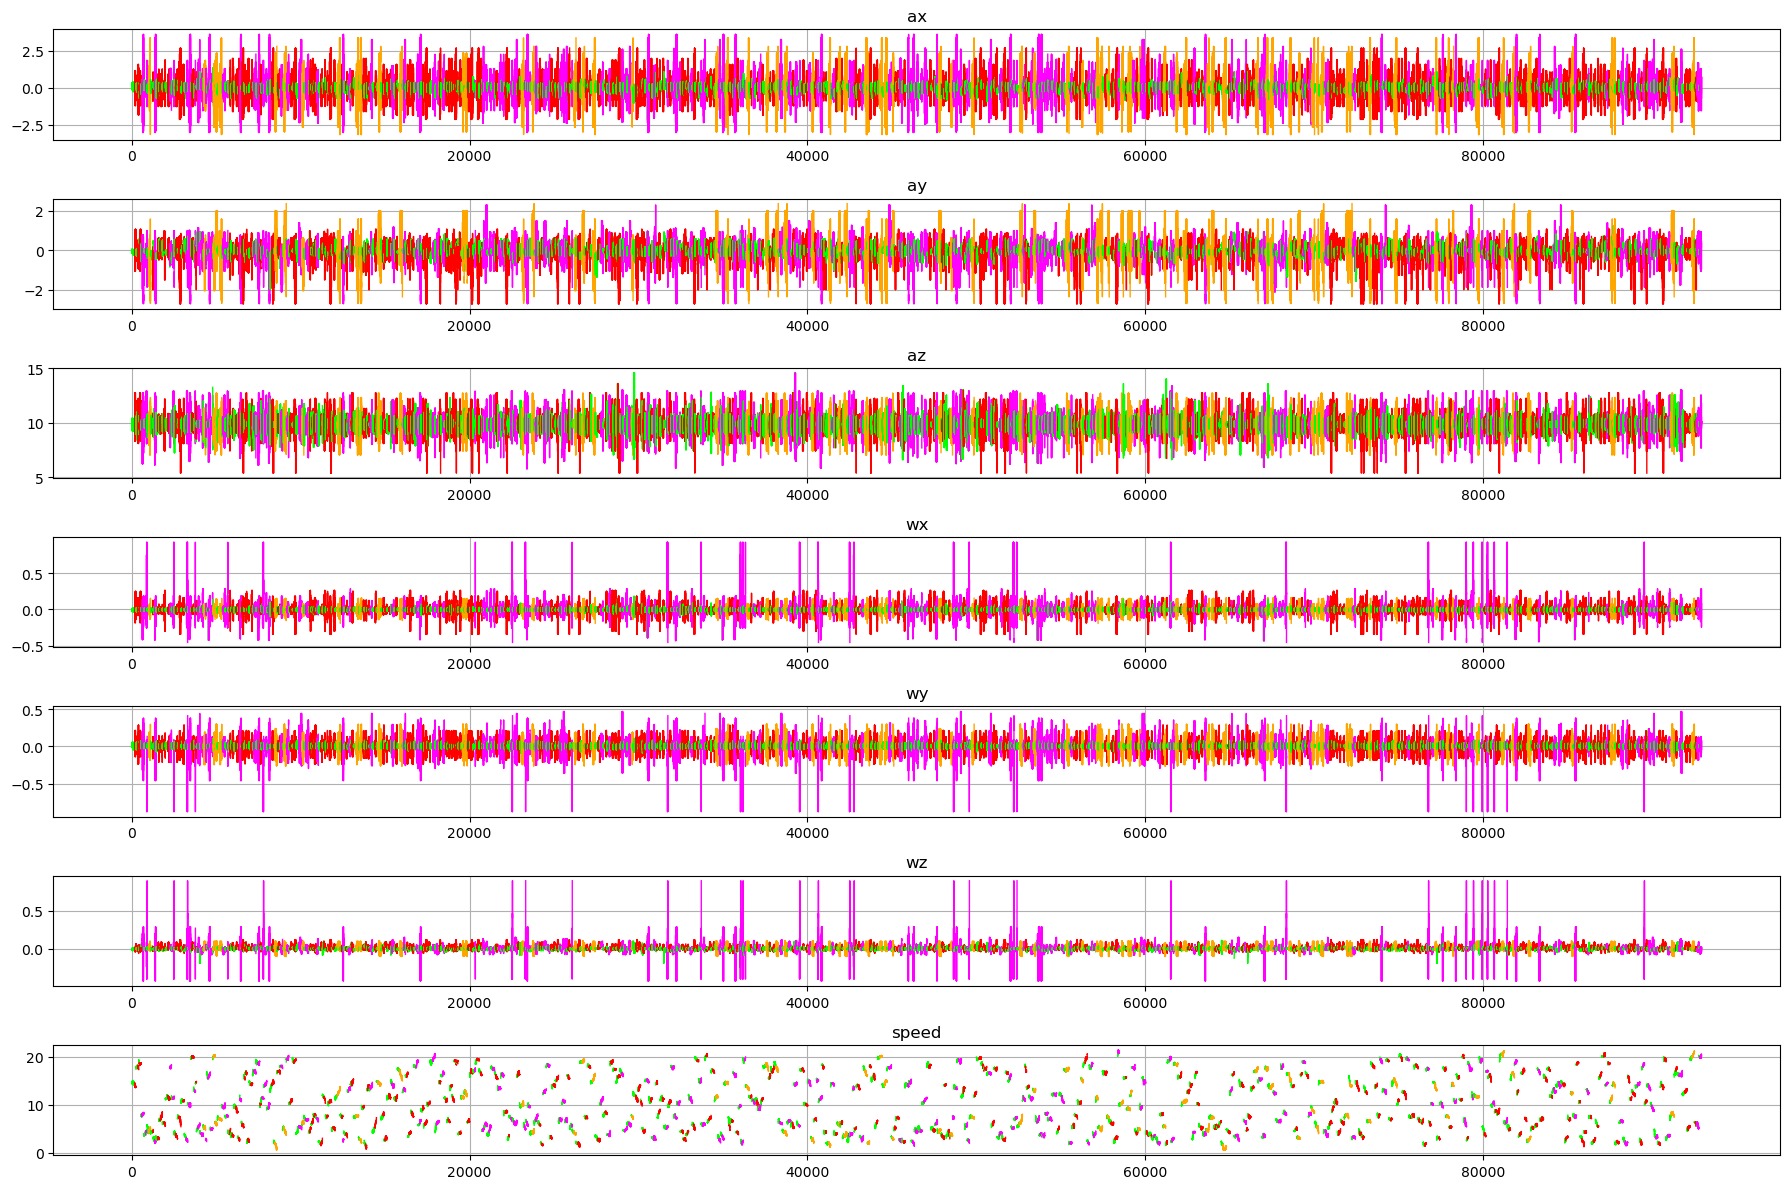

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ===== Color mapping =====
label_colors = {
    0: "#00FF00",   # green
    1: "#FFA500",   # orange
    2: "#FF0000",   # red
    3: "#FF00FF"    # magenta
}

features = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed']
x_full = np.arange(len(train))

plt.figure(figsize=(18, 12))

for idx, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, idx)

    start = 0
    while start < len(train):
        current_label = train['label'].iloc[start]
        end = start

        # find continuous segment with same label
        while end < len(train) and train['label'].iloc[end] == current_label:
            end += 1

        plt.plot(
            x_full[start:end],
            train[feature].iloc[start:end],
            color=label_colors[current_label],
            linewidth=1
        )

        start = end

    plt.title(feature)
    plt.grid(True)

plt.tight_layout()
plt.show()


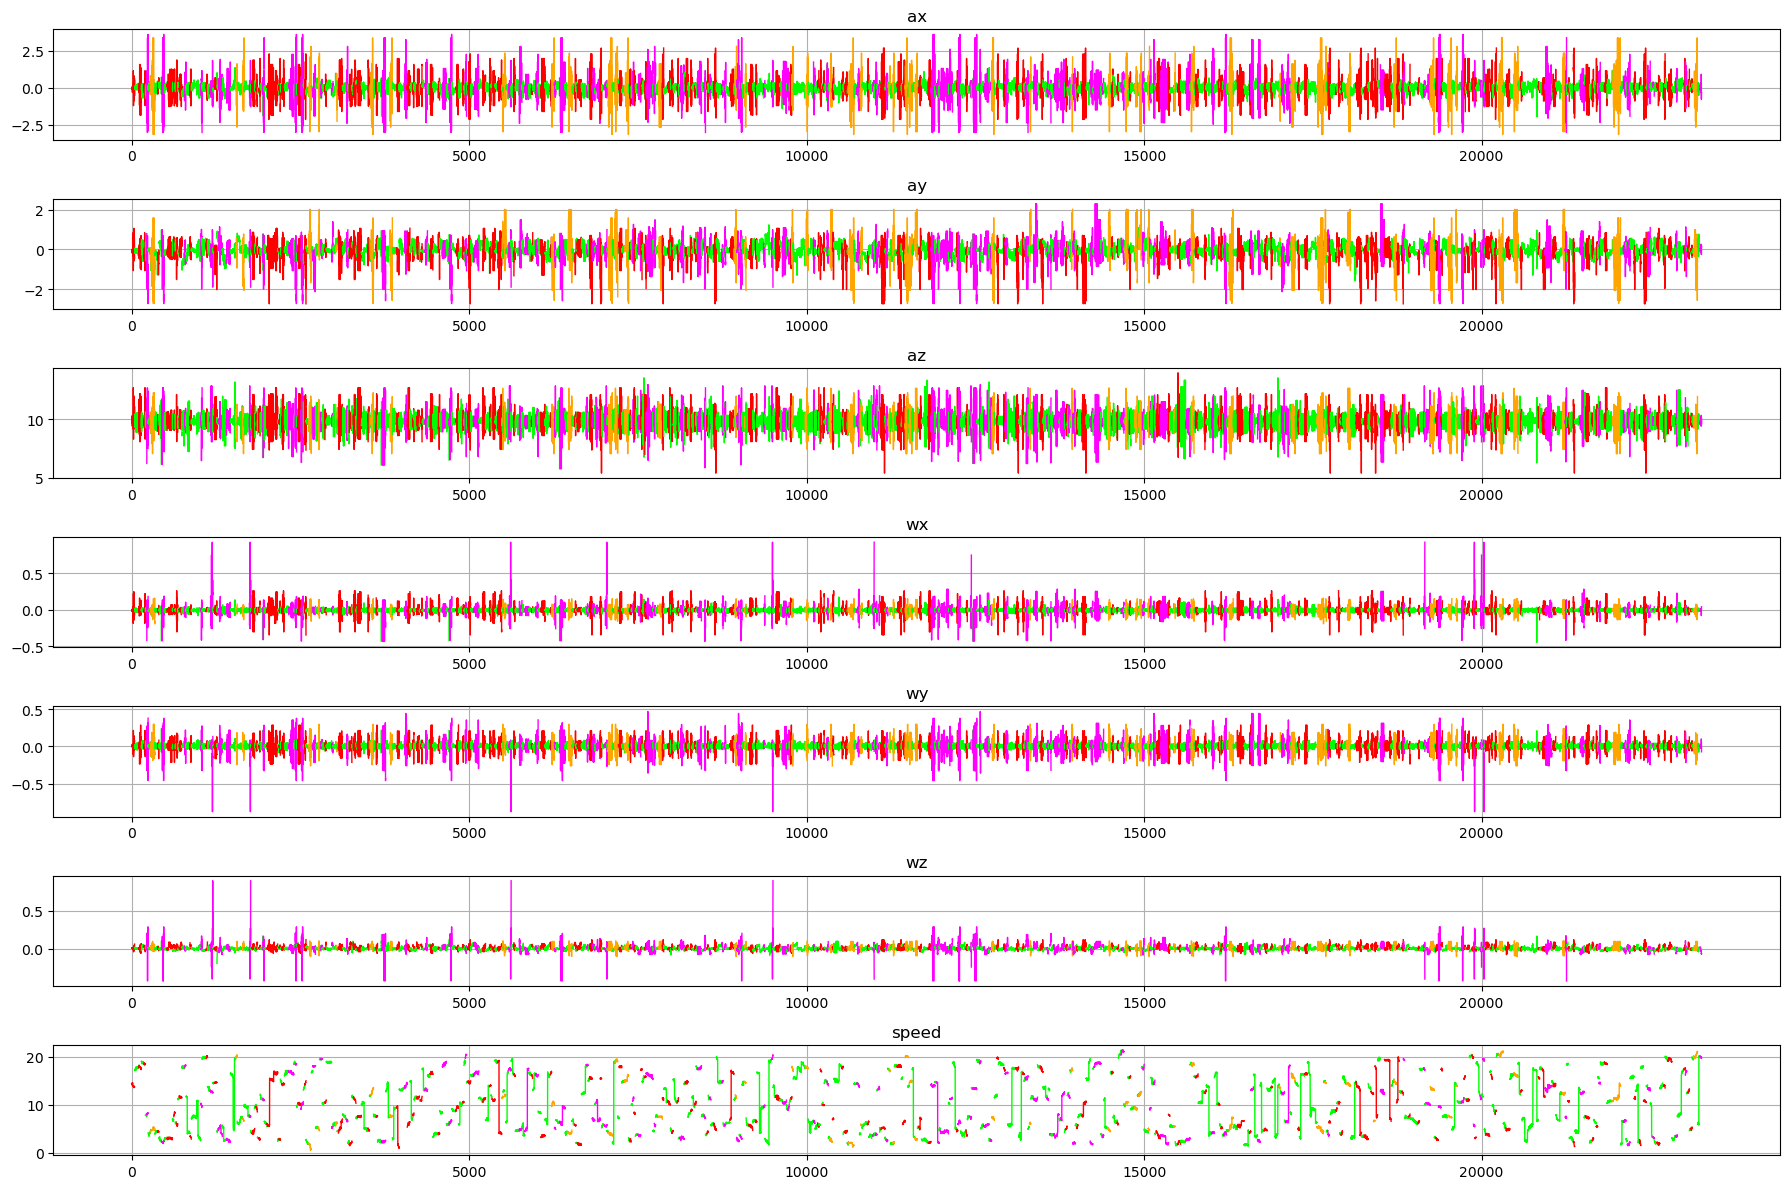

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ===== Color mapping =====
label_colors = {
    0: "#00FF00",   # green
    1: "#FFA500",   # orange
    2: "#FF0000",   # red
    3: "#FF00FF"    # magenta
}

features = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed']
x_full = np.arange(len(test))

plt.figure(figsize=(18, 12))

for idx, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, idx)

    start = 0
    while start < len(test):
        current_label = test['label'].iloc[start]
        end = start

        # find continuous segment with same label
        while end < len(test) and test['label'].iloc[end] == current_label:
            end += 1

        plt.plot(
            x_full[start:end],
            test[feature].iloc[start:end],
            color=label_colors[current_label],
            linewidth=1
        )

        start = end

    plt.title(feature)
    plt.grid(True)

plt.tight_layout()
plt.show()


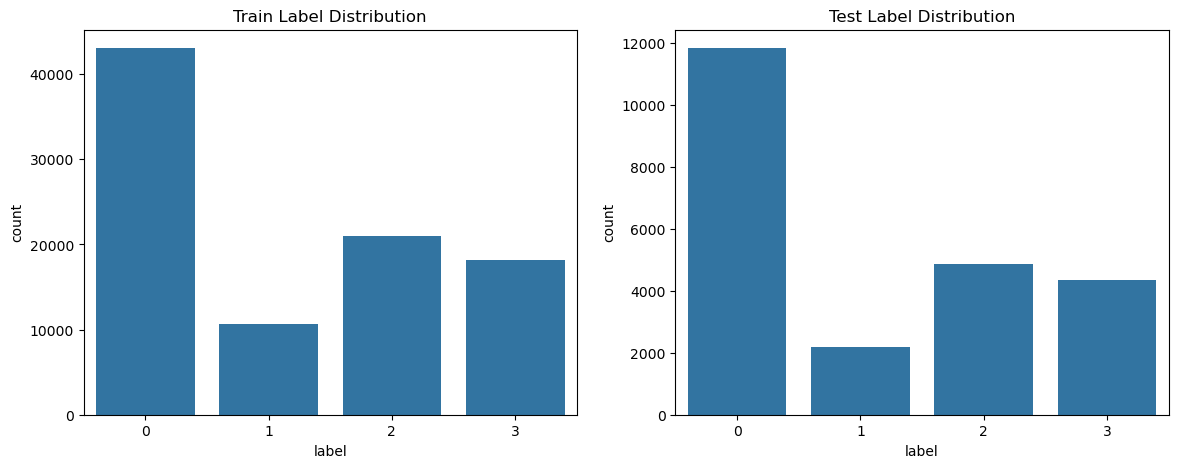

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='label', data=train, ax=axes[0])
axes[0].set_title('Train Label Distribution')

sns.countplot(x='label', data=test, ax=axes[1])
axes[1].set_title('Test Label Distribution')

plt.show()



### 1. Data Reshaping & Feature Extraction
We need to convert the long-form CSV structure into the dual-input format: 3D tensors for the CNN and 2D vectors for the MLP.

In [25]:
def extract_stat_features(series, stats_row):
    stats_row.append(np.mean(series))
    stats_row.append(np.std(series))
    stats_row.append(np.sqrt(np.mean(series**2)))  # RMS
    stats_row.append(np.max(series) - np.min(series))  # Range

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        stats_row.append(stats.skew(series, bias=False))
        stats_row.append(stats.kurtosis(series, fisher=True, bias=False))

def prepare_dual_input(df, scalers=None):
    feature_cols = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed']
    groups = [group for _, group in df.groupby('window_id')]

    # ===== CNN INPUT (unchanged) =====
    X_cnn_raw = np.array([g[feature_cols].values for g in groups])

    # ===== MLP INPUT (physics + stats features) =====
    X_mlp_raw = []

    for g in groups:
        stats_row = []

        wx, wy = g['wx'].values, g['wy'].values
        az, ay = g['az'].values, g['ay'].values

        # ---- Original physics features ----
        cov = pearsonr(wx, wy)[0] if (np.std(wx) > 1e-5 and np.std(wy) > 1e-5) else 0
        roll_ratio = np.std(wy) / (np.std(wx) + 1e-6)
        slope = np.mean(np.gradient(wx[:10]))

        stats_row.extend([
            cov,
            roll_ratio,
            slope,
            np.min(az),
            np.ptp(az),
            np.mean(ay),
            np.mean(g['speed'])
        ])

        # ---- NEW: statistical features per signal ----
        for col in feature_cols:
            series = g[col].values
            extract_stat_features(series, stats_row)

        X_mlp_raw.append(stats_row)

    X_mlp_raw = np.array(X_mlp_raw)
    X_mlp_raw = np.nan_to_num(X_mlp_raw)
    X_cnn_raw = np.nan_to_num(X_cnn_raw)
    y = np.array([g['label'].iloc[0] for g in groups])

    # ===== Scaling =====
    if scalers is None:
        sc_cnn = StandardScaler()
        sc_mlp = StandardScaler()

        N, T, F = X_cnn_raw.shape
        X_cnn = sc_cnn.fit_transform(X_cnn_raw.reshape(-1, F)).reshape(N, T, F)
        X_mlp = sc_mlp.fit_transform(X_mlp_raw)

        return X_cnn, X_mlp, y, (sc_cnn, sc_mlp)
    else:
        sc_cnn, sc_mlp = scalers

        N, T, F = X_cnn_raw.shape
        X_cnn = sc_cnn.transform(X_cnn_raw.reshape(-1, F)).reshape(N, T, F)
        X_mlp = sc_mlp.transform(X_mlp_raw)

        return X_cnn, X_mlp, y

# Execute Preparation
X_train_cnn, X_train_mlp, y_train, scalers = prepare_dual_input(train)

X_test_cnn, X_test_mlp, y_test = prepare_dual_input(test, scalers=scalers)

# ===== MANUAL OVERSAMPLING =====
from sklearn.utils import resample
print("Original Class Distribution:", np.bincount(y_train))

# Combine for resampling
train_indices = np.arange(len(y_train))
X_resampled_idx = []
y_resampled = []

class_counts = np.bincount(y_train)
max_samples = np.max(class_counts)

for label in range(len(class_counts)):
    indices = train_indices[y_train == label]
    if len(indices) == 0: continue
    
    # Upsample
    upsampled_indices = resample(indices, replace=True, n_samples=max_samples, random_state=42)
    X_resampled_idx.extend(upsampled_indices)
    y_resampled.extend([label] * max_samples)

X_resampled_idx = np.array(X_resampled_idx)
# Shuffle
shuffle_idx = np.random.permutation(len(X_resampled_idx))
X_resampled_idx = X_resampled_idx[shuffle_idx]
y_train = np.array(y_resampled)[shuffle_idx]

X_train_cnn = X_train_cnn[X_resampled_idx]
X_train_mlp = X_train_mlp[X_resampled_idx]

print("Resampled Class Distribution:", np.bincount(y_train))


# Save scalers for mobile pre-processing
joblib.dump(scalers[0], 'scaler_cnn.pkl')
joblib.dump(scalers[1], 'scaler_mlp.pkl')

Original Class Distribution: [2154  535 1048  911]
Resampled Class Distribution: [2154 2154 2154 2154]


['scaler_mlp.pkl']

### 2. Model Architecture & Training
This implements the hybrid structure we discussed, joining the temporal pattern recognition of the CNN with the explicit physics logic of the MLP.

In [26]:
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers

class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss'):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.reshape(y_true, [-1]) # Ensure flat
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        weight = self.alpha * y_true_oh * tf.math.pow((1 - y_pred), self.gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))


def build_hybrid_model():
    l2 = regularizers.l2(1e-4)

    # ===== CNN Branch: Temporal Learning =====
    cnn_in = layers.Input(shape=(20, 7), name="CNN_Input")

    x1 = layers.Conv1D(64, 3, padding='same', activation='relu', kernel_regularizer=l2)(cnn_in)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.SpatialDropout1D(0.2)(x1)

    x1 = layers.Conv1D(128, 3, padding='same', activation='relu', kernel_regularizer=l2)(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.SpatialDropout1D(0.2)(x1)

    x1 = layers.GlobalMaxPooling1D()(x1)

    # ===== MLP Branch: Logical Features =====
    mlp_in = layers.Input(shape=(49,), name="MLP_Input")

    x2 = layers.Dense(64, activation='relu', kernel_regularizer=l2)(mlp_in)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.3)(x2)

    x2 = layers.Dense(32, activation='relu', kernel_regularizer=l2)(x2)
    x2 = layers.Dropout(0.3)(x2)

    # ===== Fusion =====
    combined = layers.Concatenate()([x1, x2])

    z = layers.Dense(128, activation='relu', kernel_regularizer=l2)(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(64, activation='relu', kernel_regularizer=l2)(z)
    z = layers.Dropout(0.4)(z)

    output = layers.Dense(4, activation='softmax')(z)

    model = models.Model(inputs=[cnn_in, mlp_in], outputs=output)

    opt = optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=opt,
        loss=SparseFocalLoss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    return model
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "best_hybrid_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
model = build_hybrid_model()

history = model.fit(
    x=[X_train_cnn, X_train_mlp],
    y=y_train,
    validation_data=([X_test_cnn, X_test_mlp], y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/10
268/270 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5693 - loss: 0.2426
Epoch 1: val_loss improved from None to 0.06886, saving model to best_hybrid_model.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7010 - loss: 0.1568 - val_accuracy: 0.9407 - val_loss: 0.0689 - learning_rate: 0.0010
Epoch 2/10
267/270 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8631 - loss: 0.0826
Epoch 2: val_loss improved from 0.06886 to 0.05343, saving model to best_hybrid_model.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8822 - loss: 0.0759 - val_accuracy: 0.9647 - val_loss: 0.0534 - learning_rate: 0.0010
Epoch 3/10
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9180 - loss: 0.0640
Epoch 3: val_loss improved from 0.05343 to 0.05030, saving model to best_hybrid_model.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9286 - loss: 0.0613 - val_accuracy: 0.9716 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 4/10
266/270 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9484 - loss: 0.0558
Epoch 4: val_loss improved from 0.05030 to 0.04649, saving model to best_hybrid_model.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9501 - loss: 0.0535 - val_accuracy: 0.9768 - val_loss: 0.0465 - learning_rate: 0.0010
Epoch 5/10
263/270 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9624 - loss: 0.0475
Epoch 5: val_loss improved from 0.04649 to 0.04305, saving model to best_hybrid_model.h5


...

270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9681 - loss: 0.0442 - val_accuracy: 0.9845 - val_loss: 0.0403 - learning_rate: 0.0010
Epoch 7/10
263/270 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9741 - loss: 0.0410
Epoch 7: val_loss improved from 0.04025 to 0.03809, saving model to best_hybrid_model.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9747 - loss: 0.0400 - val_accuracy: 0.9862 - val_loss: 0.0381 - learning_rate: 0.0010
Epoch 8/10
267/270 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9796 - loss: 0.0379
Epoch 8: val_loss improved from 0.03809 to 0.03545, saving model to best_hybrid_model.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9798 - loss: 0.0365 - val_accuracy: 0.9862 - val_loss: 0.0354 - learning_rate: 0.0010
Epoch 9/10
267/270 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9799 - loss: 0.0349
Epoch 9: val_loss improved from 0.03545 to 0.03474, saving model to best_hybrid_model.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9781 - loss: 0.0345 - val_accuracy: 0.9845 - val_loss: 0.0347 - learning_rate: 0.0010
Epoch 10/10
268/270 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9854 - loss: 0.0314
Epoch 10: val_loss improved from 0.03474 to 0.03159, saving model to best_hybrid_model.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9833 - loss: 0.0317 - val_accuracy: 0.9871 - val_loss: 0.0316 - learning_rate: 0.0010


### 3. Deployment Conversion (.h5 & .tflite)
To run this on the edge, we save the Keras model and convert it to a quantized TensorFlow Lite format.

In [27]:
# Save Keras Model
model.save("pothole_severity_model.h5")

# Convert to TFLite for mobile use
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Quantization for speed
tflite_model = converter.convert()

with open("pothole_model.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmpitscu78q\assets


INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmpitscu78q\assets


Saved artifact at 'C:\Users\nishk\AppData\Local\Temp\tmpitscu78q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 20, 7), dtype=tf.float32, name='CNN_Input'), TensorSpec(shape=(None, 49), dtype=tf.float32, name='MLP_Input')]
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2706269150848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706269157360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706269152960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706269147504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706269155248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706269146272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706215342976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706267893152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706267892800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2706267886

### 4. Performance Evaluation
We visualize the Confusion Matrix to ensure the model distinguishes between vibrations (1) and medium potholes (3) effectively.

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


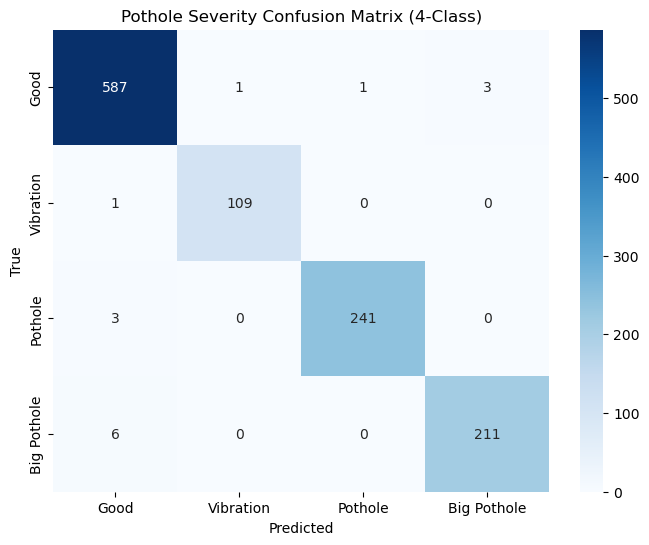

Classification Report:
              precision    recall  f1-score   support

        Good       0.98      0.99      0.99       592
   Vibration       0.99      0.99      0.99       110
     Pothole       1.00      0.99      0.99       244
 Big Pothole       0.99      0.97      0.98       217

    accuracy                           0.99      1163
   macro avg       0.99      0.99      0.99      1163
weighted avg       0.99      0.99      0.99      1163



In [29]:
# --- UPDATED EVALUATION CODE ---

# Define names for the new 4-class structure
class_names = ['Good', 'Vibration', 'Pothole', 'Big Pothole']

y_pred = np.argmax(model.predict([X_test_cnn, X_test_mlp]), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
# Updated xticklabels and yticklabels from range(5) to class_names
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Pothole Severity Confusion Matrix (4-Class)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Also update the classification report to avoid errors
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))